# Задание 6. RNA-seq: FastQC, trimming, STAR, StringTie, HTSeq-count



**Часть 1- Контроль качества исходных данных FastQC/MultiQC**

В работе использовались paired-end RNA-seq риды:


/home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R1_001.fastq.gz
/home/STUDY/FBMF/bioinformatics/rnaseq_map_star/raw_data/Eg_Treg_S71_R2_001.fastq.gz


Для исходных файлов был выполнен контроль качества с помощью FastQC. Затем результаты FastQC были объединены в общий отчёт MultiQC.

Результаты находятся в папках:


fastqc_raw/

multiqc_raw/multiqc_report.html

В MultiQC были проанализированы основные метрики качества: качество оснований по позициям рида, содержание адаптеров, overrepresented sequences, GC content и уровень дупликации.


### Результаты FastQC/MultiQC для исходных ридов

По отчёту FastQC/MultiQC для исходных данных получились такие статусы:

| Метрика | Raw R1 | Raw R2 |
|---|---|---|
| Per base sequence quality | PASS | PASS |
| Adapter Content | PASS | PASS |
| Overrepresented sequences | FAIL | PASS |

По этим результатам видно, что выраженного загрязнения адаптерами нет, так как Adapter Content имеет статус PASS для обоих файлов. Также сильного падения качества на концах ридов не наблюдается, потому что Per base sequence quality тоже имеет статус PASS для R1 и R2.

Основная проблема была в файле R1: модуль Overrepresented sequences имел статус FAIL, т е в R1 есть последовательности, которые встречаются чаще ожидаемого. Так как при этом Adapter Content имеет статус PASS, эти последовательности, скорее всего, не являются стандартными адаптерами.

**Часть 2 -  Тримминг fastp и повторный контроль качества**

Тримминг был выполнен программой fastp. Использовались автоматическое определение адаптеров для paired-end данных, обрезка низкокачественных участков на концах ридов с порогом Q20 и удаление слишком коротких ридов длиной менее 30 нуклеотидов.

После тримминга были получены файлы:


trimmed/Eg_Treg_S71_R1.trimmed.fastq.gz

trimmed/Eg_Treg_S71_R2.trimmed.fastq.gz


Также fastp создал отчёты:


trimmed/fastp_report.html

trimmed/fastp_report.json


По отчёту fastp:


Duplication rate: 6.24%

Insert size peak: 119 bp


После тримминга был повторно выполнен FastQC/MultiQC. Результаты находятся в:


fastqc_trimmed/

multiqc_trimmed/multiqc_report.html



### Что изменилось после тримминга

После тримминга статусы стали такими:

| Метрика | Trimmed R1 | Trimmed R2 |
|---|---|---|
| Per base sequence quality | PASS | PASS |
| Adapter Content | PASS | PASS |
| Overrepresented sequences | WARN | PASS |

После fastp качество ридов осталось хорошим: Per base sequence quality и Adapter Content остались PASS для обоих файлов. Проблема с Overrepresented sequences в R1 улучшилась с FAIL до WARN. Это может говорить о том, что эти последовательности, не были обычными адаптерами.

Для дальнейшего выравнивания были выбраны триммированные риды, потому что они прошли дополнительную очистку от потенциальных адаптерных фрагментов и низкокачественных концов.


**Часть 3 - Выравнивание на референсный геном STAR**

Выравнивание триммированных paired-end ридов на референсный геном GRCh38 было выполнено с помощью STAR.

Входные файлы:


trimmed/Eg_Treg_S71_R1.trimmed.fastq.gz

trimmed/Eg_Treg_S71_R2.trimmed.fastq.gz


Основные выходные файлы:


star_alignment/RNA_Aligned.sortedByCoord.out.bam

star_alignment/RNA_Log.final.out

star_alignment/RNA_ReadsPerGene.out.tab



### Основные результаты STAR

Основные результаты из файла RNA_Log.final.out :

```text
Number of input reads: 19046818
Average input read length: 149
Uniquely mapped reads number: 15834380
Uniquely mapped reads %: 83.13%
Number of reads mapped to multiple loci: 1102876
% of reads mapped to multiple loci: 5.79%
Number of reads mapped to too many loci: 91051
% of reads mapped to too many loci: 0.48%
Number of reads unmapped: too short: 1977028
% of reads unmapped: too short: 10.38%
Number of reads unmapped: other: 41483
% of reads unmapped: other: 0.22%
Mismatch rate per base: 0.69%
```

Большая часть ридов успешно выровнялась на геном — 83.13%. Это выглядит как хороший результат, что не может не радовать, и говорит о нормальном качестве данных и подходящем референсном геноме. Часть ридов не выровнялась, в основном из-за категории too short — 10.38%. Это может быть связано как с качеством отдельных ридов, так и с тем, что после тримминга часть фрагментов стала слишком короткой для уверенного выравнивания.


**Скриншот статистики STAR, часть 1**

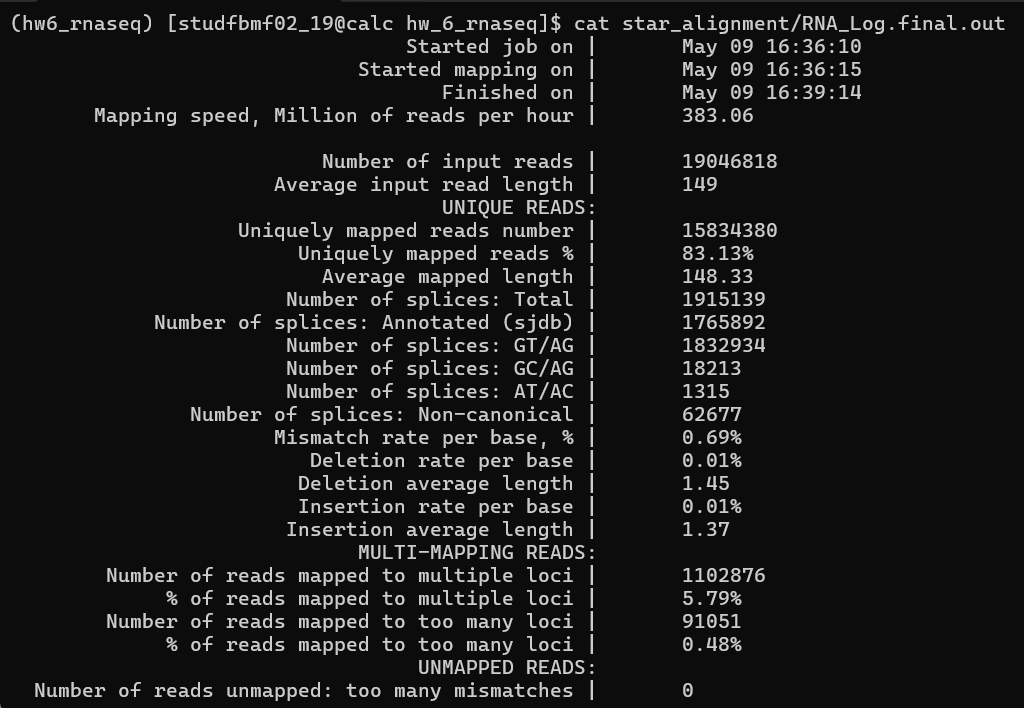


**Скриншот статистики STAR, часть 2**

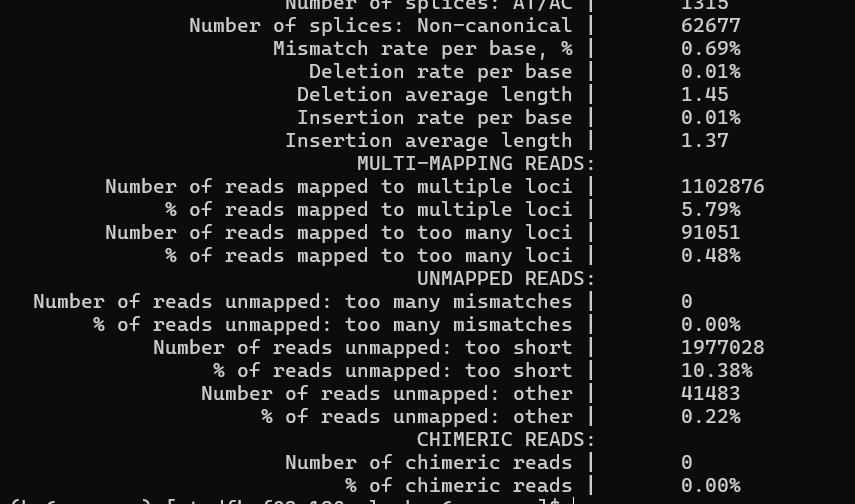


## StringTie

После STAR был запущен StringTie на BAM-файле:


star_alignment/RNA_Aligned.sortedByCoord.out.bam


В результате был получен файл:


stringtie_out/transcripts.gtf


Первые 10 строк файла transcripts.gtf:

```text
# stringtie star_alignment/RNA_Aligned.sortedByCoord.out.bam -o stringtie_out/transcripts.gtf -p 4
# StringTie version 3.0.3
1   StringTie   transcript   75902   77168   1000   .   .   gene_id "STRG.1"; transcript_id "STRG.1.1"; cov "5.611888"; FPKM "2.246660"; TPM "4.817608";
1   StringTie   exon         75902   77168   1000   .   .   gene_id "STRG.1"; transcript_id "STRG.1.1"; exon_number "1"; cov "5.611888";
1   StringTie   transcript   91658   92659   1000   .   .   gene_id "STRG.2"; transcript_id "STRG.2.1"; cov "9.275534"; FPKM "3.713362"; TPM "7.962718";
1   StringTie   exon         91658   92659   1000   .   .   gene_id "STRG.2"; transcript_id "STRG.2.1"; exon_number "1"; cov "9.275534";
1   StringTie   transcript   94864   96518   1000   .   .   gene_id "STRG.3"; transcript_id "STRG.3.1"; cov "4.839462"; FPKM "1.937427"; TPM "4.154507";
1   StringTie   exon         94864   96518   1000   .   .   gene_id "STRG.3"; transcript_id "STRG.3.1"; exon_number "1"; cov "4.839462";
1   StringTie   transcript   99112   102057  1000   .   .   gene_id "STRG.4"; transcript_id "STRG.4.1"; cov "4.875245"; FPKM "1.951753"; TPM "4.185226";
1   StringTie   exon         99112   102057  1000   .   .   gene_id "STRG.4"; transcript_id "STRG.4.1"; exon_number "1"; cov "4.875245";
```

В GTF-файле присутствуют стандартные поля: chromosome, source, feature type, start, end, score, strand, frame и attributes. В данном файле chromosome = 1, source = StringTie, feature type показывает тип записи (transcript или exon), start и end задают координаты на геноме, а в поле attributes указаны gene_id, transcript_id, cov, FPKM, TPM и exon_number для exon-записей.

Количество собранных транскриптов - 92826


StringTie нужен для сборки транскриптов по BAM-файлу после выравнивания и оценки их abundance. Файл transcripts.gtf можно использовать для описания структуры транскриптов, поиска возможных новых изоформ и дальнейшего анализа экспрессии.


**Скриншот первых строк transcripts.gtf**

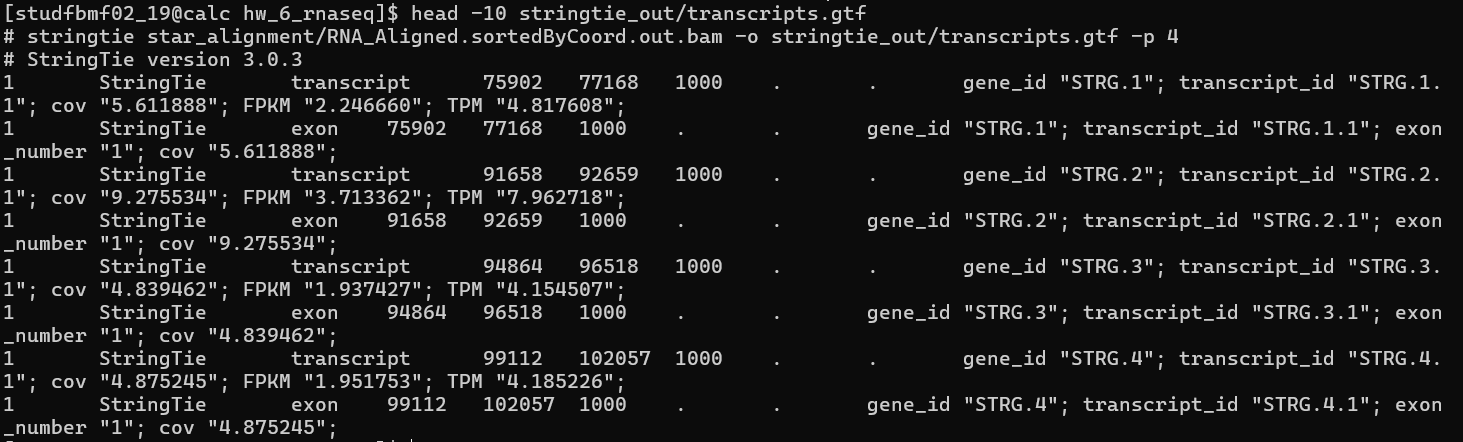


**Часть 4 - HTSeq-count**

Для подсчёта ридов по генам был использован HTSeq-count.

Входные файлы:


star_alignment/RNA_Aligned.sortedByCoord.out.bam

/home/STUDY/FBMF/bioinformatics/GRCh38/Homo_sapiens.GRCh38.110.chr.gtf


Использованные параметры:


--format bam

--order pos

--stranded no

--type exon

--idattr gene_id


Эти параметры означают, что входной файл был в формате BAM, он отсортирован по координатам, библиотека рассматривалась как unstranded, подсчёт выполнялся по экзонам, а идентификатор гена брался из поля gene_id.

Результат был сохранён в файл:


htseq/htseq_counts.txt


Количество уникальных генов без служебных строк HTSeq - 62700


Служебные категории HTSeq:


__no_feature: 12101917
__ambiguous: 619510
__too_low_aQual: 0
__not_aligned: 0
__alignment_not_unique: 1102876


Большое значение __no_feature означает, что много ридов не было отнесено к экзонам аннотированных генов. Это может быть связано с попаданием ридов в интронные или межгенные области. Категория __ambiguous означает, что рид мог относиться больше чем к одному гену, а __alignment_not_unique — что рид выровнялся неуникально.


## Сравнение STAR GeneCounts и HTSeq-count

Для сравнения использовались каунты STAR из файла:


star_alignment/RNA_ReadsPerGene.out.tab


По условию задания была взята колонка 3. Каунты HTSeq были взяты из файла:


htseq/htseq_counts.txt


Служебные строки были удалены, затем таблицы были объединены по gene_id.

Результаты сравнения:


Number of STAR genes: 62700

Number of HTSeq genes: 62700

Number of common genes: 62700

Pearson correlation: 0.7472469612949296

Spearman correlation: 0.9322161828023767


Были построены scatter plots:


plots/star_vs_htseq_scatter.png

plots/star_vs_htseq_scatter_log.png



**График 1. STAR GeneCounts vs HTSeq-count**

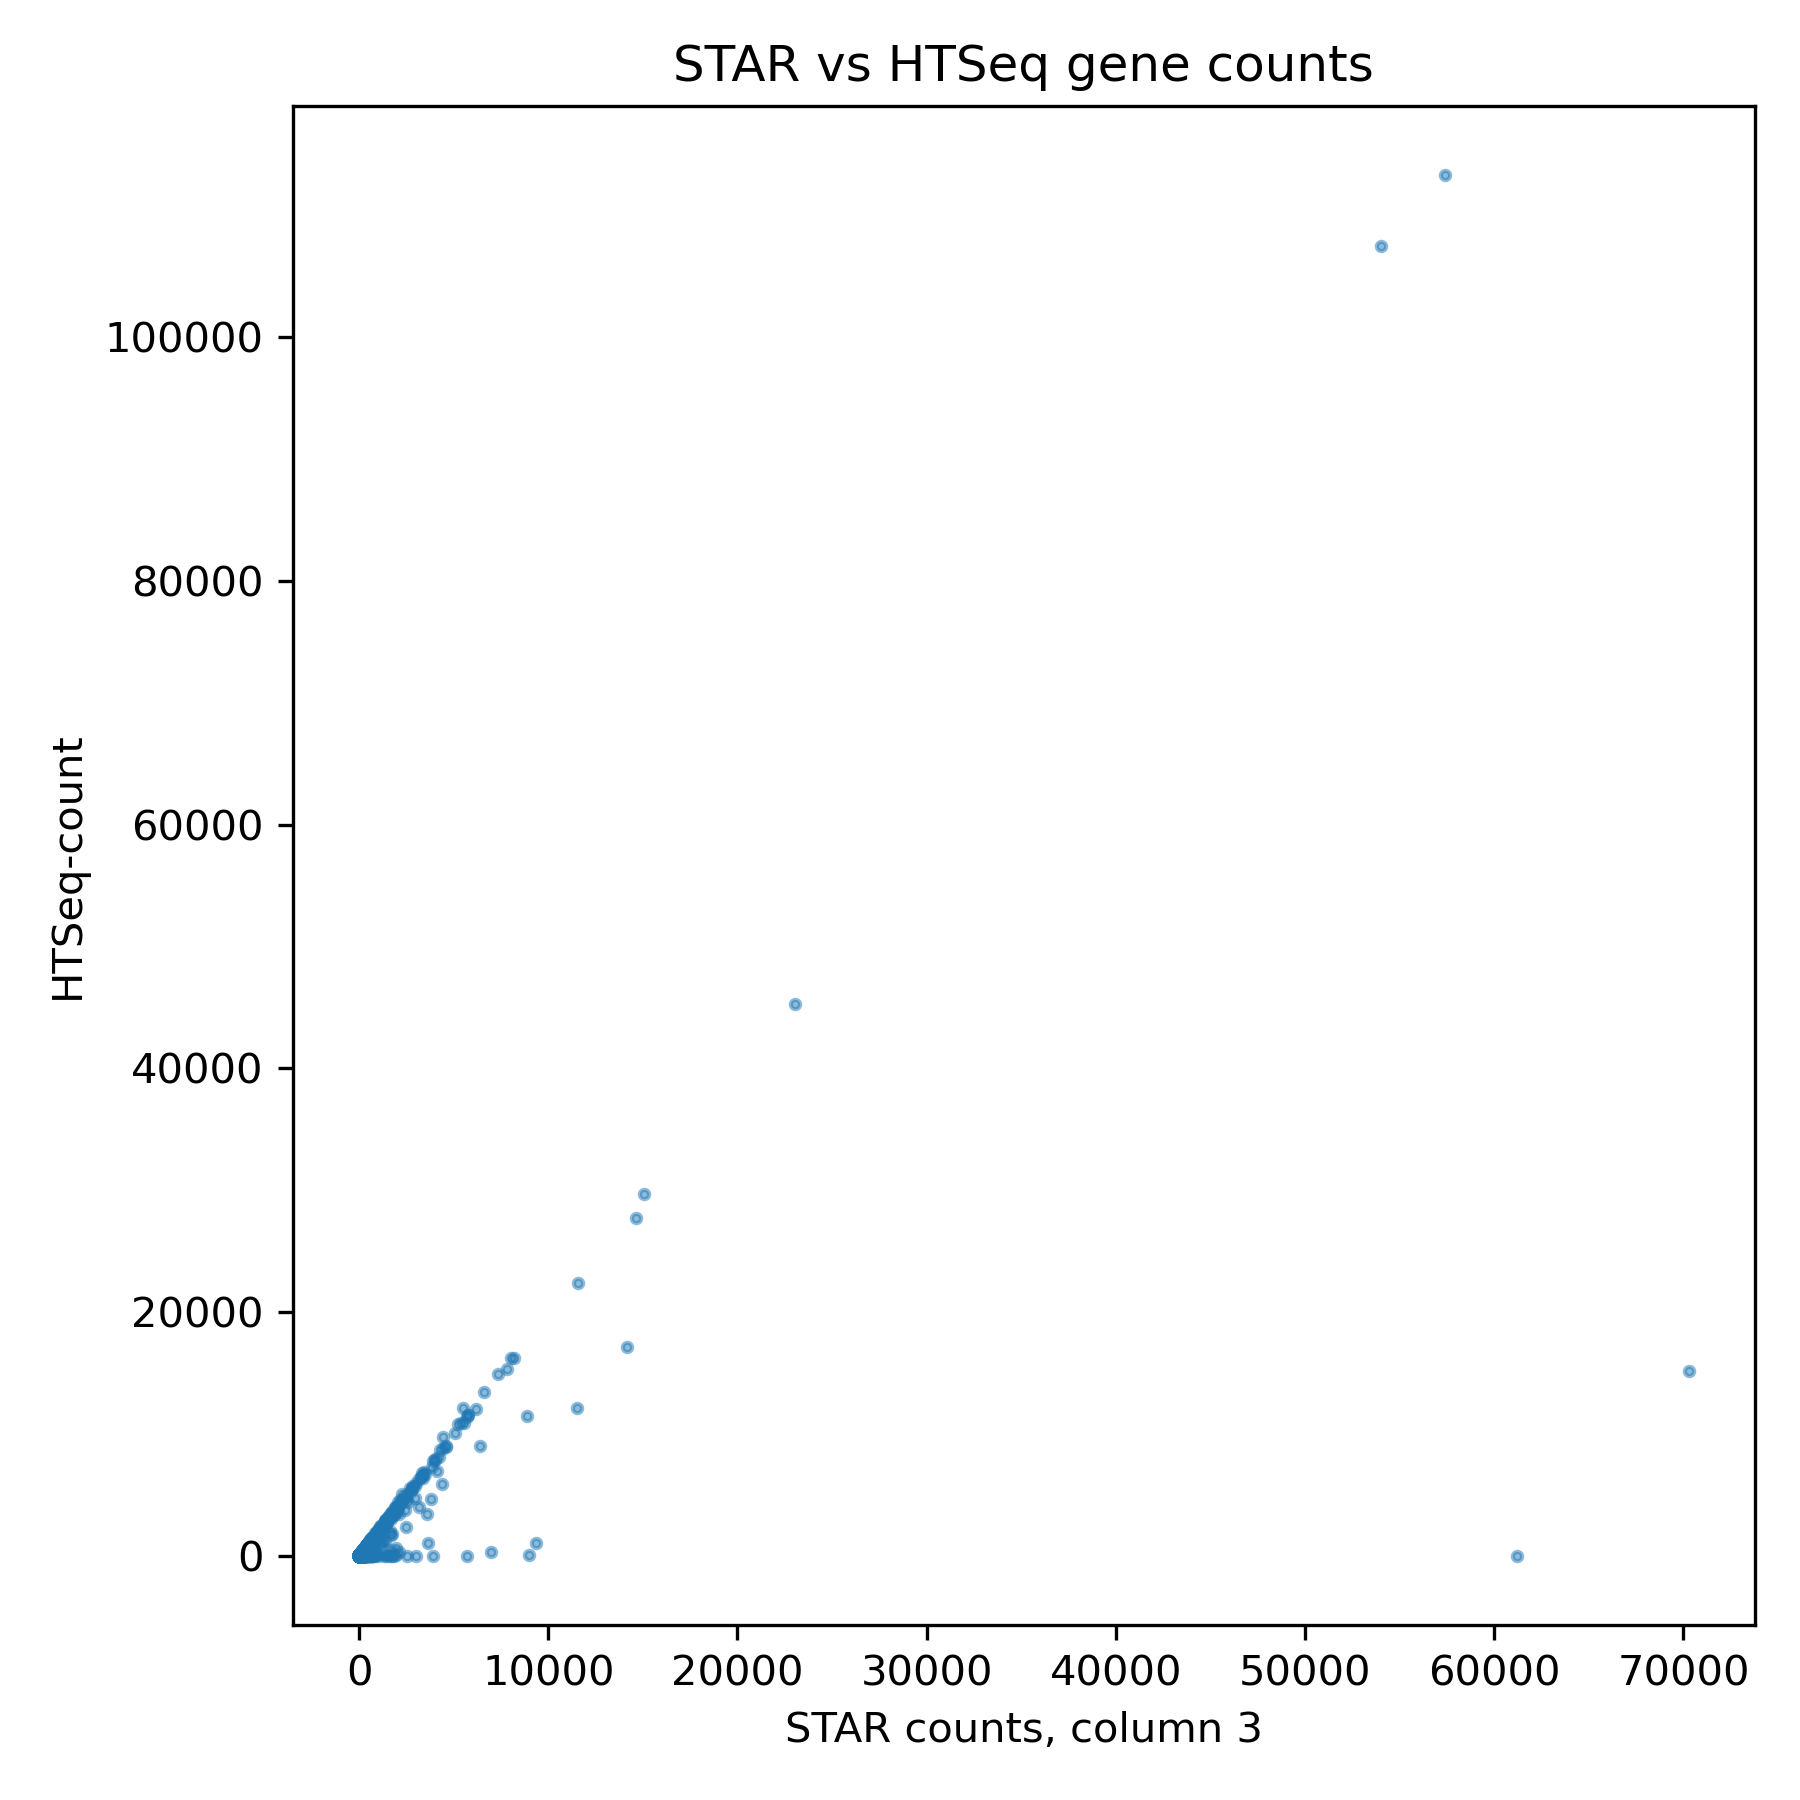


**График 2. STAR GeneCounts vs HTSeq-count, логарифмическая шкала**

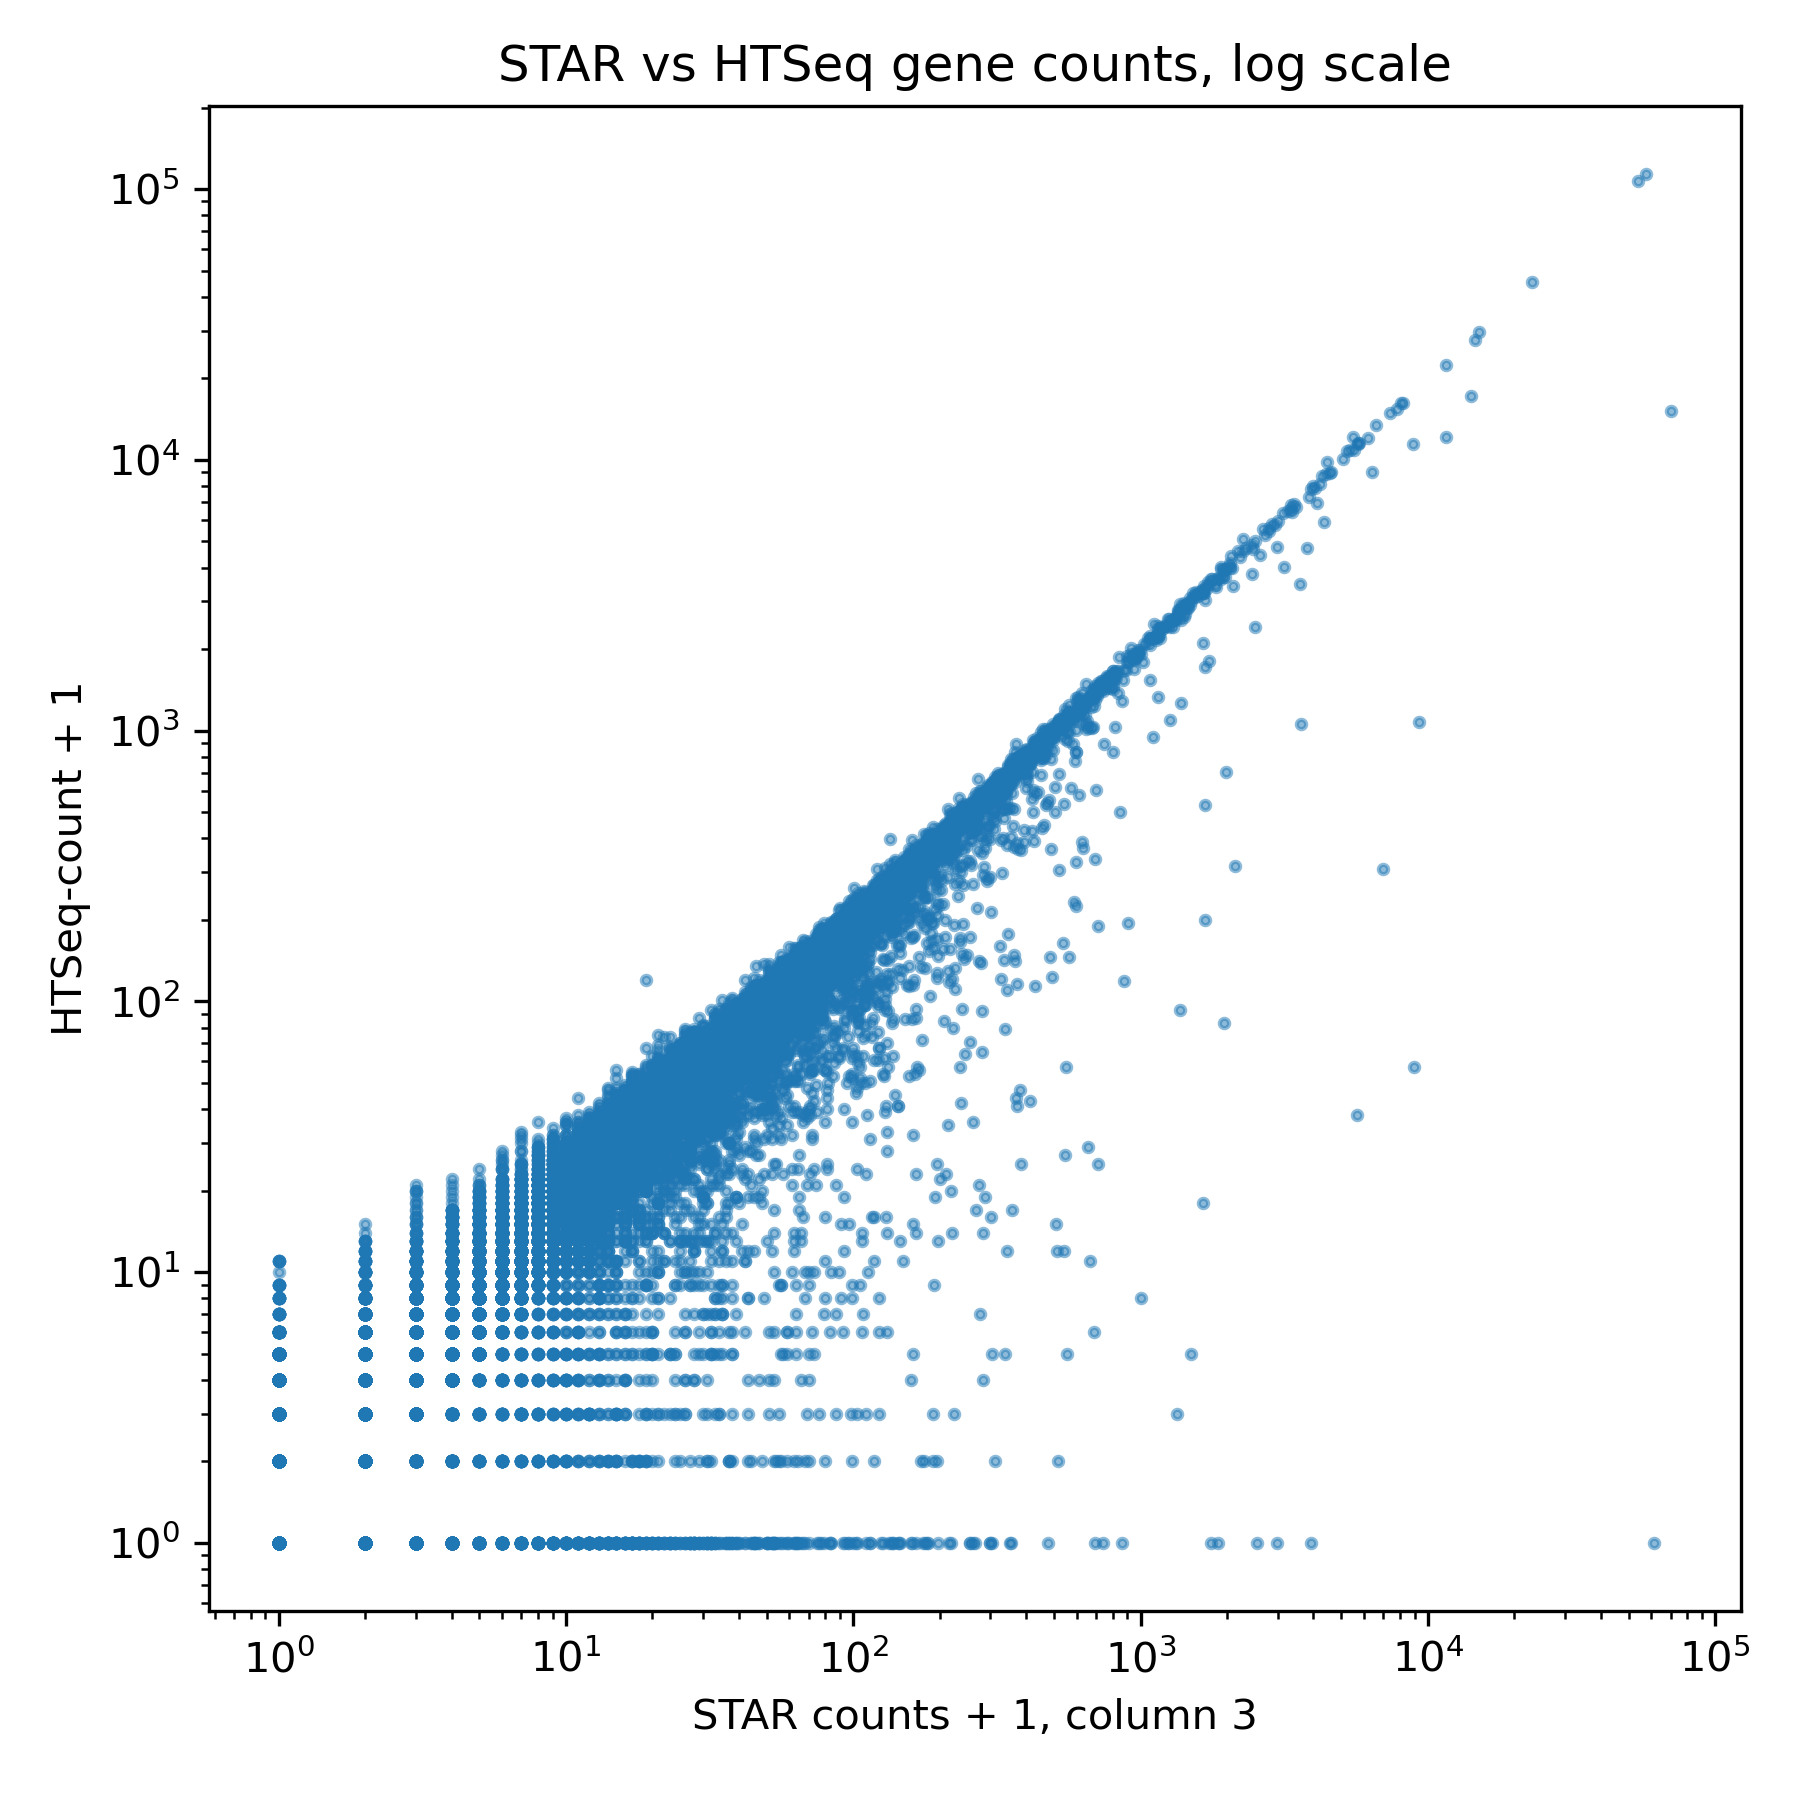


### Интерпретация корреляции и различий

Корреляция Спирмена получилась высокой — 0.93. Это значит, что ранги экспрессии генов в STAR и HTSeq хорошо согласуются: гены с высокими каунтами в одном методе обычно имеют высокие каунты и в другом методе.

Корреляция Пирсона ниже — около 0.75. Это означает, что абсолютные значения каунтов для части генов отличаются.

Результаты STAR GeneCounts и HTSeq-count могут не совпадать, потому что эти программы используют разные алгоритмы подсчёта ридов по генам. Различия могут возникать из-за неоднозначно выровненных ридов, мультимаппинга, ридов, попадающих в пересекающиеся гены или экзоны, а также из-за разных правил обработки категорий ambiguous и  no_feature.


## Что лучше использовать для дальнейшего DE-анализа

Я бы использовала HTSeq-count, потому что эта программа специально предназначена для подсчёта ридов по генам. В ней явно задаётся GTF-файл с аннотацией, указывается, что считать нужно по exon, и что идентификатор гена берётся из gene_id. Поэтому понятнее, как именно были получены каунты.

STAR GeneCounts тоже даёт таблицу каунтов, и это удобно, потому что она получается сразу после выравнивания. Но этот вариант менее гибкий: в STAR меньше возможностей контролировать правила подсчёта ридов по генам.

В моём результате STAR и HTSeq в целом хорошо согласуются: корреляция Спирмена получилась 0.93. Но корреляция Пирсона ниже — 0.75, значит абсолютные значения каунтов у части генов отличаются.

## Скриншот папки на сервере

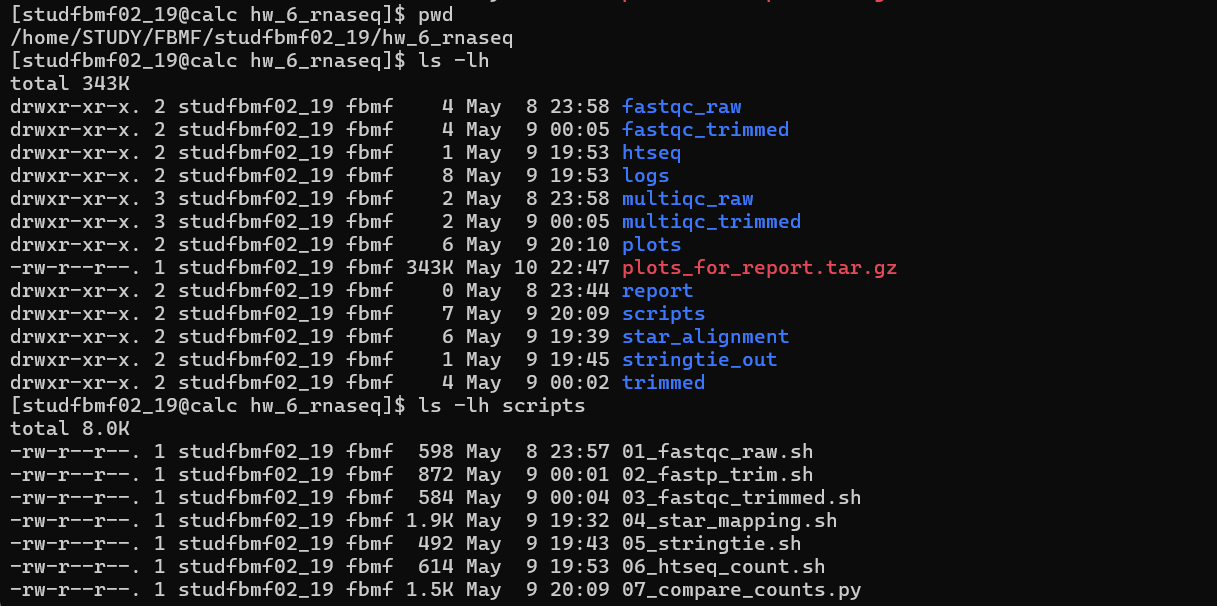

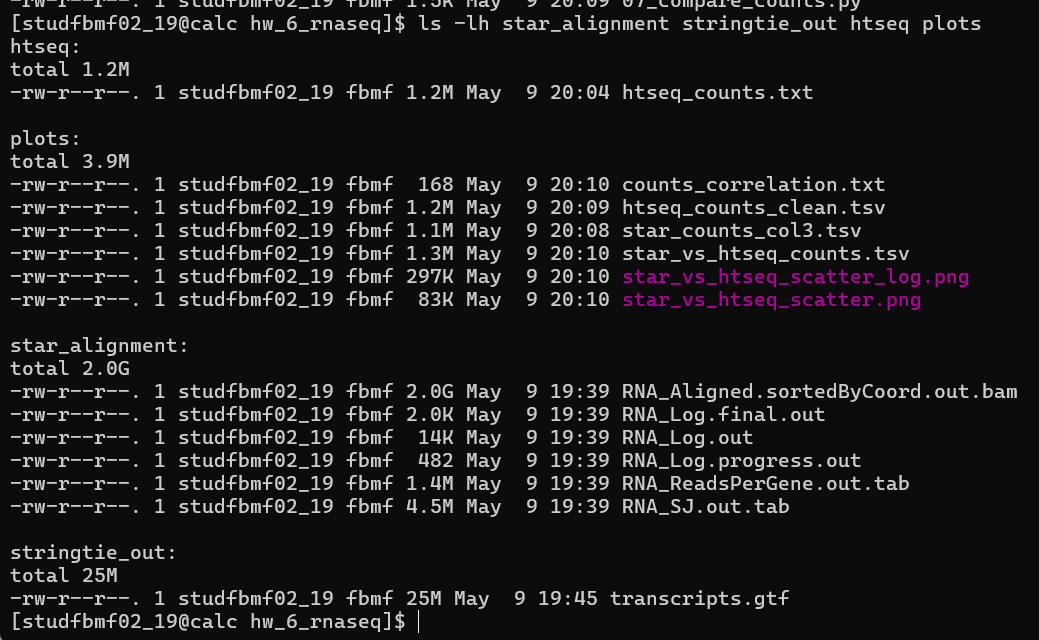

## Вывод

В этой работе было выполнено: контроль качества исходных ридов, тримминг, повторный контроль качества, выравнивание на референсный геном, сборка транскриптов, подсчёт каунтов по генам и сравнение STAR GeneCounts с HTSeq-count.

Исходные данные были хорошего качества: адаптеры выраженно не обнаружены, качество оснований по позициям было хорошим. Основная проблема была в Overrepresented sequences для R1, но после тримминга она улучшилась с FAIL до WARN.

STAR показал 83.13% уникально выровненных ридов. StringTie собрал 92826 транскриптов. HTSeq-count дал каунты для 62700 генов. Сравнение STAR и HTSeq показало высокую корреляцию Спирмена, но не полное совпадение абсолютных каунтов, что может быть весьма ожидаемо из-за различий в алгоритмах подсчёта.

Для дальнейшего DE-анализа в DESeq2 или edgeR я бы использовала HTSeq-count, потому что в нём можно явно задать параметры, такие как  GTF-файл, тип feature exon как тип признака, атрибут gene_id какидентификатор гена и strandedness, это помогает облегчить интерпритацию таких каунтов.
